# Farmyard sound event detection

End-to-end walkthrough of the `src/` pipeline: a frozen YAMNet backbone with a trained bidirectional-GRU head, trained on continuous synthetic mixtures, with per-class post-processing tuned on a validation set and scored with a 0.5 s collar.

This notebook loads the already-trained model in `models/` and shows detection on a sample recording plus the collar metrics. Training and tuning are run from the CLI (`python -m src.train`, `python -m src.tune`); see the README.

In [1]:
import os
# run from the repo root so ./data and ./models resolve
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# macOS TF Hub SSL fix + offline cache
import certifi
os.environ.setdefault('SSL_CERT_FILE', certifi.where())
os.environ.setdefault('REQUESTS_CA_BUNDLE', certifi.where())
os.environ.setdefault('TFHUB_CACHE_DIR', os.path.expanduser('~/.cache/tfhub_modules'))
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
%matplotlib inline
print('cwd:', os.getcwd())

cwd: /Users/kikugo/Downloads/audio/sound2species


## Data split

The seed clips (ESC-50, enriched so `others` covers many background categories) are split at the source-recording level, so takes of one recording never straddle the train/val/test boundary.

In [2]:
from src.data_generator import scan_classes, source_level_split
catalog = scan_classes('data/enriched')
splits = source_level_split(catalog, seed=42)
for name in ['train', 'val', 'test']:
    print(name, {k: len(v) for k, v in splits[name].items()})

train {'dog': 26, 'cat': 26, 'sheep': 30, 'cow': 28, 'rooster': 29, 'others': 1230}
val {'dog': 5, 'cat': 6, 'sheep': 5, 'cow': 6, 'rooster': 4, 'others': 286}
test {'dog': 9, 'cat': 8, 'sheep': 5, 'cow': 6, 'rooster': 7, 'others': 284}


## Detection on a sample recording

Load the trained model and run the full pipeline on one test mixture. The output is the event list (the JSON deliverable) and the visualization (waveform + spectrogram with per-class event lanes).

/Users/kikugo/Downloads/audio/sound2species/.venv/lib/python3.11/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Loading YAMNet from https://tfhub.dev/google/yamnet/1 ...


loaded tuned post-processing from models/postprocess.json


/Users/kikugo/Downloads/audio/sound2species/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


file: test_mix_000.wav
[
  {
    "animal": "cat",
    "event_start": 15.84,
    "event_end": 17.28,
    "confidence": 0.9158011078834534
  },
  {
    "animal": "dog",
    "event_start": 38.88,
    "event_end": 41.28,
    "confidence": 0.9650017619132996
  }
]


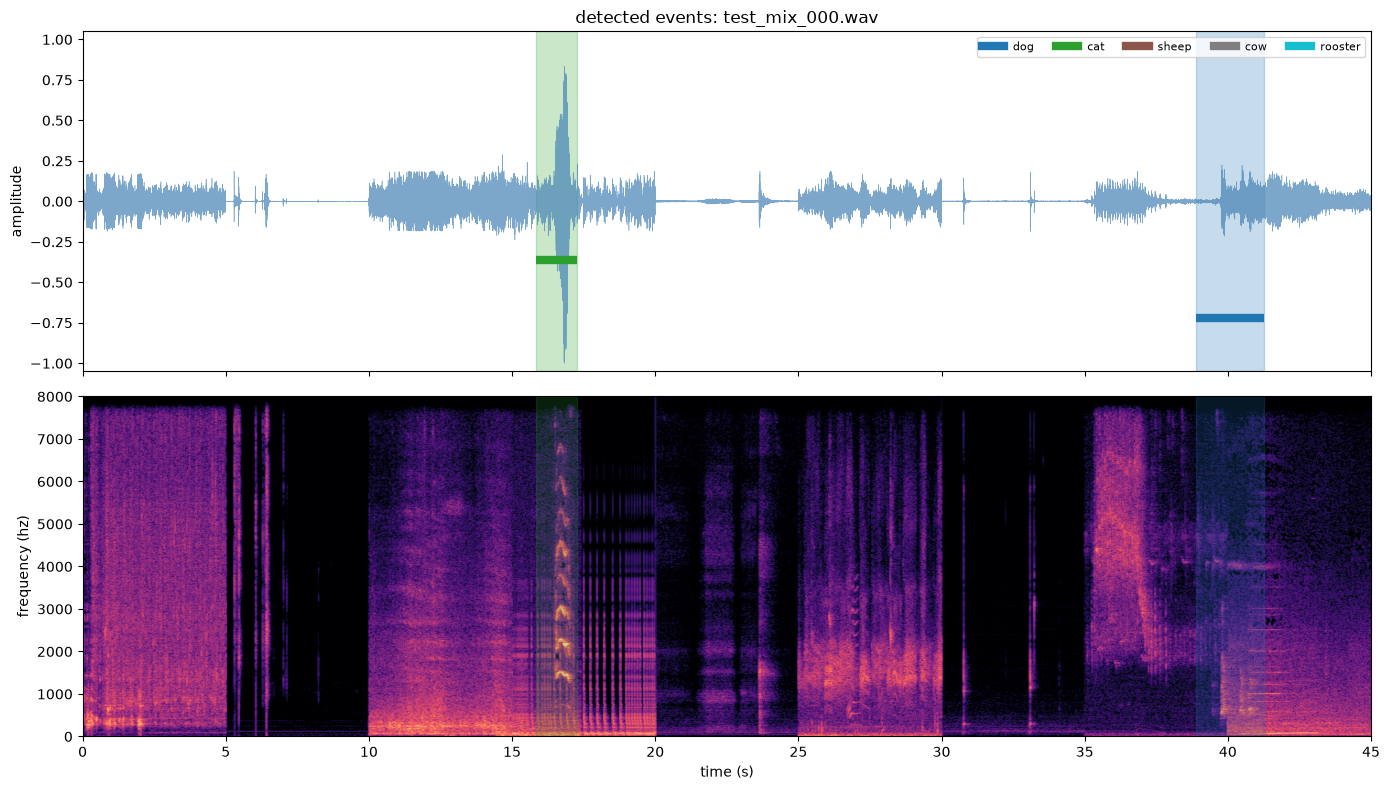

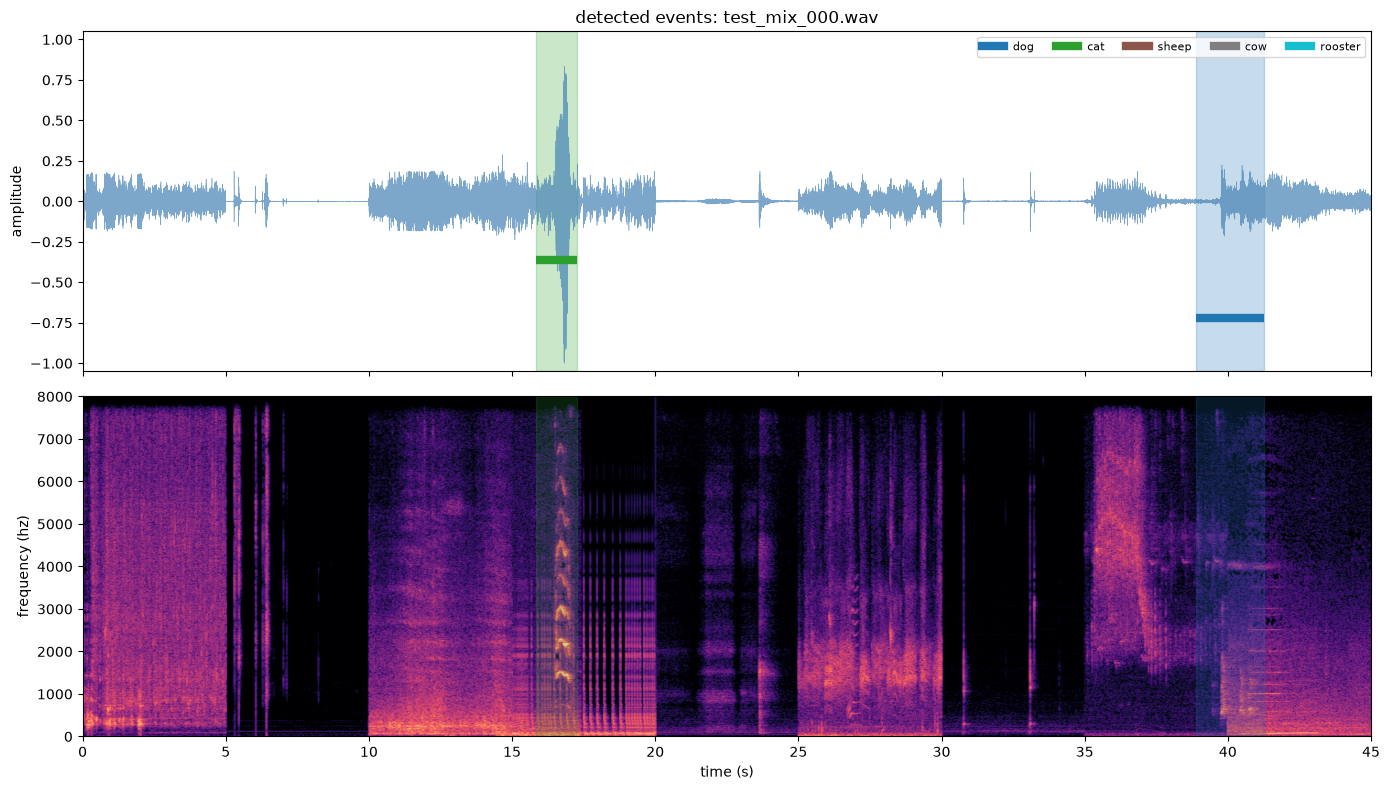

In [3]:
import glob, json
from src.pipeline import FarmyardSEDPipeline
pipeline = FarmyardSEDPipeline(model_dir='models')
wav = sorted(glob.glob('data/eval/*.wav'))[0]
events, fig = pipeline.process_file(wav)
print('file:', os.path.basename(wav))
print(json.dumps(events, indent=2))
fig

## Collar-based evaluation

Event F1 with a 0.5 s collar on a handful of held-out test mixtures, reported both onset-only and strict onset+offset, plus the per-class frame diagnostic. (The full test set is larger; a subset is used here to keep the notebook quick.)

In [4]:
import glob, shutil, os
os.makedirs('data/eval_demo', exist_ok=True)
for w in sorted(glob.glob('data/eval/*.wav'))[:8]:
    shutil.copy(w, 'data/eval_demo/')
    shutil.copy(w[:-4] + '.json', 'data/eval_demo/')
from src.evaluate import evaluate, frame_confusion
_ = evaluate('data/eval_demo', 'models')
frame_confusion('data/eval_demo', 'models')

Loading YAMNet from https://tfhub.dev/google/yamnet/1 ...


loaded tuned post-processing from models/postprocess.json


=== onset + offset (strict) ===
Event based metrics (onset-offset)
  Evaluated length                  : 276.22 sec
  Evaluated files                   : 8 
  Evaluate onset                    : True 
  Evaluate offset                   : True 
  T collar                          : 500.00 ms
  Offset (length)                   : 0.00 %

  Overall metrics (micro-average)
  F-measure
    F-measure (F1)                  : 15.38 %
    Precision                       : 25.00 %
    Recall                          : 11.11 %
  Error rate
    Error rate (ER)                 : 1.22 
    Substitution rate               : 0.00 
    Deletion rate                   : 0.89 
    Insertion rate                  : 0.33 

  Class-wise average metrics (macro-average)
  F-measure
    F-measure (F1)                  : 20.00 %
    Precision                       : 20.00 %
    Recall                          : 20.00 %
  Error rate
    Error rate (ER)                 : 1.09 
    Deletion rate                  

loaded tuned post-processing from models/postprocess.json



frame-level per-class (diagnostic):
  class    precision  recall     tp     fp     fn
  dog          0.667   0.296      8      4     19
  cat          0.667   0.316      6      3     13
  sheep        1.000   0.812     13      0      3
  cow          0.000   0.000      0      5     21
  rooster      0.529   0.310      9      8     20
  others       0.900   0.987    624     69      8
